In [12]:
!pip install dagshub mlflow plotly

In [13]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import mlflow
import mlflow.tensorflow
import dagshub
import plotly.graph_objects as go

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

In [14]:
from kaggle_secrets import UserSecretsClient
secret_label = "dagshub_token"
secret_value = UserSecretsClient().get_secret(secret_label)

In [15]:
os.environ["MLFLOW_TRACKING_USERNAME"] = "Aryanupadhyay23"
os.environ["MLFLOW_TRACKING_PASSWORD"] = secret_value

mlflow.set_tracking_uri(
    "https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow"
)

mlflow.set_experiment("resnet50")

<Experiment: artifact_location='mlflow-artifacts:/4a68a28d2d694062b9ed905bf6103138', creation_time=1772861952385, experiment_id='14', last_update_time=1772861952385, lifecycle_stage='active', name='resnet50', tags={}, workspace='default'>

In [16]:
DATASET_PATH = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET"

TRAIN_DIR = os.path.join(DATASET_PATH,"train")
TEST_DIR = os.path.join(DATASET_PATH,"test")

OUTPUT_DIR = "/kaggle/working/resnet50_results"
os.makedirs(OUTPUT_DIR,exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100

EMOTIONS = ['Surprise','Fear','Disgust','Happy','Sad','Anger','Neutral']
NUM_CLASSES = len(EMOTIONS)

In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="categorical",
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode="categorical",
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 12271 files belonging to 7 classes.


I0000 00:00:1772861971.656518      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 3068 files belonging to 7 classes.


In [18]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [19]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2)
])

train_ds = train_ds.map(
    lambda x,y:(data_aug(x),y),
    num_parallel_calls=AUTOTUNE
)

In [20]:
labels=[]

for _,y in train_ds.unbatch():
    labels.append(np.argmax(y.numpy()))

labels=np.array(labels)

weights = compute_class_weight(
    "balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights=dict(enumerate(weights))

print(class_weights)

{0: np.float64(1.3589147286821706), 1: np.float64(6.238434163701068), 2: np.float64(2.4449093444909344), 3: np.float64(0.3673512154233026), 4: np.float64(0.884460141271443), 5: np.float64(2.4865248226950354), 6: np.float64(0.6945324881141046)}


In [21]:
run = mlflow.start_run(run_name="resnet50_class_weights")

mlflow.log_param("model","ResNet50")
mlflow.log_param("img_size",IMG_SIZE)
mlflow.log_param("batch_size",BATCH_SIZE)
mlflow.log_param("epochs",EPOCHS)
mlflow.log_param("num_classes",NUM_CLASSES)
mlflow.log_param("augmentation","flip_rotation_zoom_contrast")
mlflow.log_param("class_weights",class_weights)

{0: np.float64(1.3589147286821706),
 1: np.float64(6.238434163701068),
 2: np.float64(2.4449093444909344),
 3: np.float64(0.3673512154233026),
 4: np.float64(0.884460141271443),
 5: np.float64(2.4865248226950354),
 6: np.float64(0.6945324881141046)}

In [22]:
base_model = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE,IMG_SIZE,3)
)

base_model.trainable=True

inputs = keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))

x = keras.applications.resnet.preprocess_input(inputs)

x = base_model(x)

attention = layers.Conv2D(
    1,
    kernel_size=1,
    activation="sigmoid"
)(x)

attention = layers.Multiply()([x,attention])

x = layers.GlobalAveragePooling2D()(attention)

x = layers.BatchNormalization()(x)

x = layers.Dense(512,activation="relu")(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128,activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(NUM_CLASSES,activation="softmax")(x)

model = keras.Model(inputs,outputs)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 1)   │      2,049 │ resnet50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 7, 7,      │          0 │ resnet50[0][0],   │
│                     │ 2048)             │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     65,664 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7)         │        903 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,713,608 (94.27 MB)

 Trainable params: 24,656,392 (94.06 MB)

 Non-trainable params: 57,216 (223.50 KB)

In [23]:
with open("model_summary.txt","w") as f:
    model.summary(print_fn=lambda x: f.write(x+"\n"))

mlflow.log_artifact("model_summary.txt")

In [24]:
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

optimizer = keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

In [25]:
callbacks=[

keras.callbacks.ModelCheckpoint(
    os.path.join(OUTPUT_DIR,"best_model.keras"),
    monitor="val_accuracy",
    save_best_only=True
),

keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True
),

keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3
)

]

In [26]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/100


I0000 00:00:1772862080.861102     188 service.cc:152] XLA service 0x7cd274002c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772862080.861152     188 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772862087.002731     188 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/384 ━━━━━━━━━━━━━━━━━━━━ 6:09:26 58s/step - accuracy: 0.1250 - loss: 2.6367

I0000 00:00:1772862108.706551     188 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


384/384 ━━━━━━━━━━━━━━━━━━━━ 160s 266ms/step - accuracy: 0.2151 - loss: 2.5167 - val_accuracy: 0.4505 - val_loss: 1.6197 - learning_rate: 1.0000e-04
Epoch 2/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 73s 189ms/step - accuracy: 0.3754 - loss: 1.8039 - val_accuracy: 0.5108 - val_loss: 1.4852 - learning_rate: 1.0000e-04
Epoch 3/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 73s 188ms/step - accuracy: 0.4693 - loss: 1.6046 - val_accuracy: 0.5737 - val_loss: 1.3535 - learning_rate: 1.0000e-04
Epoch 4/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 73s 189ms/step - accuracy: 0.5456 - loss: 1.4471 - val_accuracy: 0.6395 - val_loss: 1.2509 - learning_rate: 1.0000e-04
Epoch 5/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 73s 188ms/step - accuracy: 0.6101 - loss: 1.3387 - val_accuracy: 0.6415 - val_loss: 1.2378 - learning_rate: 1.0000e-04
Epoch 6/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 73s 190ms/step - accuracy: 0.6296 - loss: 1.3041 - val_accuracy: 0.6711 - val_loss: 1.2030 - learning_rate: 1.0000e-04
Epoch 7/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 73s 189ms/

In [27]:
for i in range(len(history.history["accuracy"])):

    mlflow.log_metric("train_accuracy",history.history["accuracy"][i],step=i)
    mlflow.log_metric("val_accuracy",history.history["val_accuracy"][i],step=i)

    mlflow.log_metric("train_loss",history.history["loss"][i],step=i)
    mlflow.log_metric("val_loss",history.history["val_loss"][i],step=i)

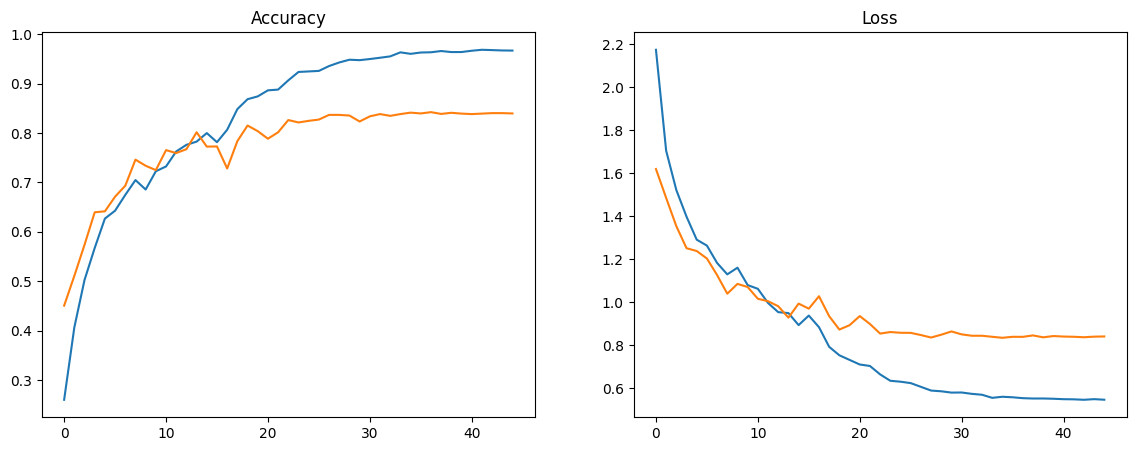

In [28]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")

curve_path=os.path.join(OUTPUT_DIR,"training_curves.png")

plt.savefig(curve_path)
mlflow.log_artifact(curve_path)

plt.show()

In [29]:
best_model = keras.models.load_model(
    os.path.join(OUTPUT_DIR,"best_model.keras")
)

y_true=[]
y_pred=[]
y_prob=[]

for x,y in test_ds:

    preds = best_model.predict(x)

    y_true.extend(np.argmax(y.numpy(),axis=1))
    y_pred.extend(np.argmax(preds,axis=1))
    y_prob.extend(preds)

y_true=np.array(y_true)
y_pred=np.array(y_pred)
y_prob=np.array(y_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━

In [30]:
acc = accuracy_score(y_true,y_pred)

print("Test Accuracy:",acc)

mlflow.log_metric("test_accuracy",acc)

Test Accuracy: 0.8422425032594524


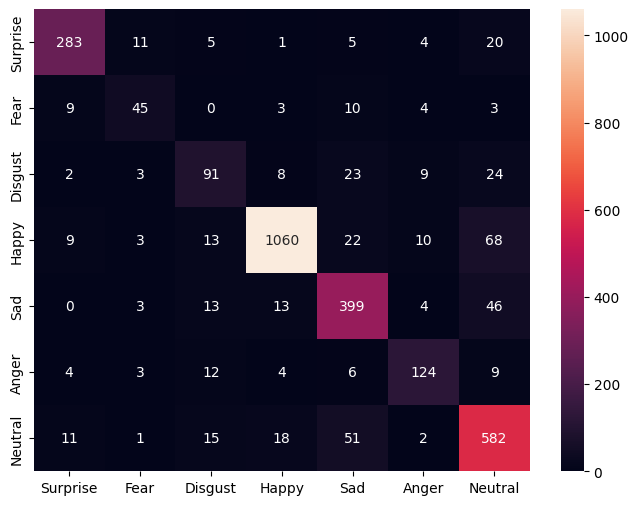

In [31]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=EMOTIONS,
    yticklabels=EMOTIONS
)

cm_path=os.path.join(OUTPUT_DIR,"confusion_matrix.png")

plt.savefig(cm_path)

mlflow.log_artifact(cm_path)

plt.show()

In [32]:
report = classification_report(
    y_true,
    y_pred,
    target_names=EMOTIONS
)

print(report)

report_path=os.path.join(OUTPUT_DIR,"classification_report.txt")

with open(report_path,"w") as f:
    f.write(report)

mlflow.log_artifact(report_path)

              precision    recall  f1-score   support

    Surprise       0.89      0.86      0.87       329
        Fear       0.65      0.61      0.63        74
     Disgust       0.61      0.57      0.59       160
       Happy       0.96      0.89      0.92      1185
         Sad       0.77      0.83      0.80       478
       Anger       0.79      0.77      0.78       162
     Neutral       0.77      0.86      0.81       680

    accuracy                           0.84      3068
   macro avg       0.78      0.77      0.77      3068
weighted avg       0.85      0.84      0.84      3068



In [33]:
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

roc_auc_macro = roc_auc_score(y_true_bin,y_prob,average="macro",multi_class="ovr")
roc_auc_micro = roc_auc_score(y_true_bin,y_prob,average="micro",multi_class="ovr")

mlflow.log_metric("roc_auc_macro",roc_auc_macro)
mlflow.log_metric("roc_auc_micro",roc_auc_micro)

print("Macro ROC AUC:",roc_auc_macro)
print("Micro ROC AUC:",roc_auc_micro)

Macro ROC AUC: 0.9443202014606077
Micro ROC AUC: 0.9676960431012648


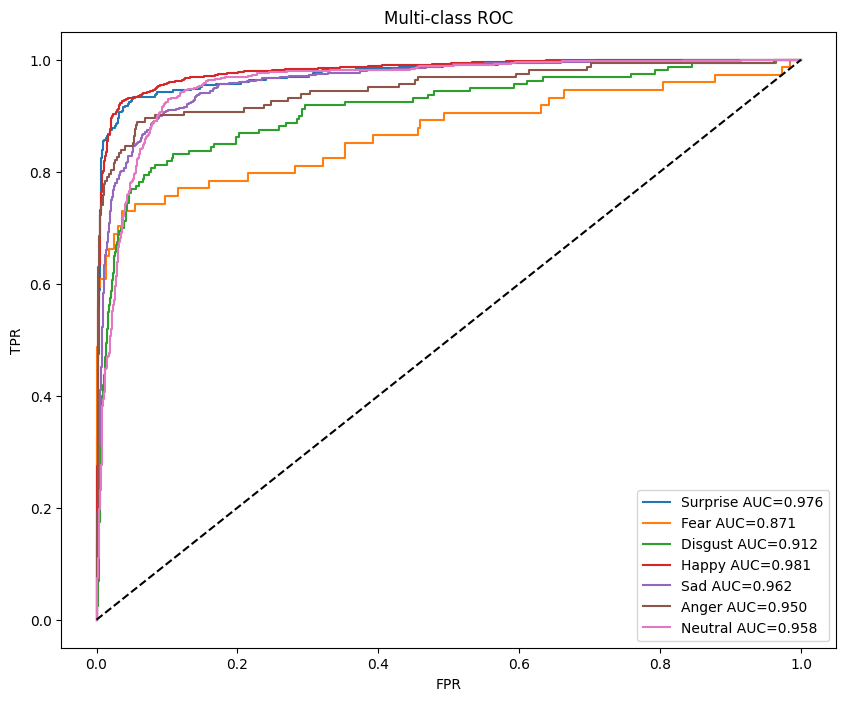

In [34]:
plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    fpr,tpr,_ = roc_curve(y_true_bin[:,i],y_prob[:,i])

    auc_score = roc_auc_score(y_true_bin[:,i],y_prob[:,i])

    mlflow.log_metric(f"roc_auc_{EMOTIONS[i]}",auc_score)

    plt.plot(fpr,tpr,label=f"{EMOTIONS[i]} AUC={auc_score:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multi-class ROC")

plt.legend()

roc_path=os.path.join(OUTPUT_DIR,"roc_curve.png")

plt.savefig(roc_path)

mlflow.log_artifact(roc_path)

plt.show()

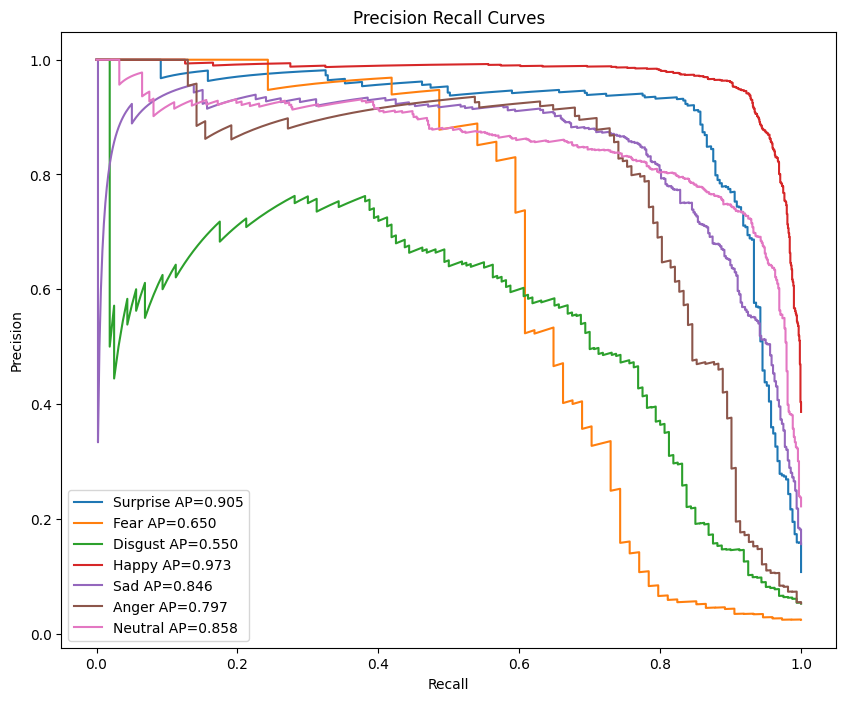

In [35]:
plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    precision,recall,_ = precision_recall_curve(
        y_true_bin[:,i],
        y_prob[:,i]
    )

    ap = average_precision_score(
        y_true_bin[:,i],
        y_prob[:,i]
    )

    mlflow.log_metric(f"ap_{EMOTIONS[i]}",ap)

    plt.plot(recall,precision,label=f"{EMOTIONS[i]} AP={ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curves")

plt.legend()

pr_path=os.path.join(OUTPUT_DIR,"precision_recall.png")

plt.savefig(pr_path)

mlflow.log_artifact(pr_path)

plt.show()

In [36]:
fig = go.Figure()

for i in range(NUM_CLASSES):

    fpr,tpr,_ = roc_curve(y_true_bin[:,i],y_prob[:,i])

    fig.add_trace(
        go.Scatter(
            x=fpr,
            y=tpr,
            mode='lines',
            name=EMOTIONS[i]
        )
    )

fig.add_shape(
    type="line",
    x0=0,y0=0,
    x1=1,y1=1,
    line=dict(dash="dash")
)

fig.update_layout(
    title="Interactive ROC Curve",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate"
)

interactive_path=os.path.join(OUTPUT_DIR,"interactive_roc.html")

fig.write_html(interactive_path)

mlflow.log_artifact(interactive_path)

In [37]:
mlflow.tensorflow.log_model(
    model,
    artifact_path="model"
)

2026/03/07 06:39:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/07 06:40:11 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [38]:
mlflow.end_run()

🏃 View run resnet50_class_weights at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/14/runs/841dd920709c461481216a584e43e5a4
🧪 View experiment at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/14
